In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_csv("eda_modified_data.csv")
data.head()

,sample_id,age_at_initial_pathologic_diagnosis,gender,PAM50Call_RNAseq,ER_Status_nature2012,PR_Status_nature2012,HER2_Final_Status_nature2012,OS_Time_nature2012,OS_event_nature2012,final_stage,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,TCGA-A1-A0SB,70.0,FEMALE,Normal,Positive,Negative,Negative,259.0,0.0,Stage I,...,0.5366,5.2962,1.7015,0.0000,9.1491,13.3508,5.8179,10.5362,4.0283,9.4571
1,TCGA-A1-A0SD,59.0,FEMALE,LumA,Positive,Positive,Negative,437.0,0.0,Stage IIA,...,0.0000,3.6145,4.3589,0.4123,9.3914,12.6757,8.9559,10.7473,8.7529,10.5299
2,TCGA-A1-A0SE,56.0,FEMALE,LumA,Positive,Positive,Negative,1320.0,0.0,Stage I,...,0.7296,0.9907,3.3525,0.0000,9.7743,12.6287,8.0530,11.0453,7.8723,9.8006
3,TCGA-A1-A0SF,54.0,FEMALE,LumA,Positive,Positive,Negative,1463.0,0.0,Stage IIA,...,0.0000,0.8928,4.4016,1.8361,9.3262,12.4998,8.0516,11.5144,7.7695,10.2341
4,TCGA-A1-A0SG,61.0,FEMALE,LumA,Positive,Positive,Negative,433.0,0.0,Stage IIB,...,0.4436,4.2479,3.8032,0.0000,8.9289,12.1010,8.0315,11.3914,7.5616,9.9156


In [9]:
gene = pd.concat([data[["sample_id"]],data.iloc[:, 18:]], axis=1)
gene.head()

,sample_id,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,TCGA-A1-A0SB,10.8075,6.0416,0.5366,11.8120,11.3068,9.9874,12.9785,2.7775,0.0000,...,0.5366,5.2962,1.7015,0.0000,9.1491,13.3508,5.8179,10.5362,4.0283,9.4571
1,TCGA-A1-A0SD,9.1657,2.4935,0.0000,11.7868,11.0131,10.5228,12.8109,4.6140,0.0000,...,0.0000,3.6145,4.3589,0.4123,9.3914,12.6757,8.9559,10.7473,8.7529,10.5299
2,TCGA-A1-A0SE,9.7179,3.3983,0.0000,11.3219,11.2617,10.3831,12.5342,4.1789,0.0000,...,0.7296,0.9907,3.3525,0.0000,9.7743,12.6287,8.0530,11.0453,7.8723,9.8006
3,TCGA-A1-A0SF,9.8581,4.9132,0.0000,11.4817,11.0700,10.2721,12.7637,3.3820,0.0000,...,0.0000,0.8928,4.4016,1.8361,9.3262,12.4998,8.0516,11.5144,7.7695,10.2341
4,TCGA-A1-A0SG,10.1198,1.6599,0.0000,11.8184,11.0909,10.2251,12.7285,3.0356,0.4436,...,0.4436,4.2479,3.8032,0.0000,8.9289,12.1010,8.0315,11.3914,7.5616,9.9156


In [11]:
gene.shape

(615, 20531)

In [13]:
gene_var = gene.iloc[:,1:].var(axis=0)

In [15]:
gene_var_sorted = gene_var.sort_values(ascending=False)

### Select top genes

In [20]:
top_genes = gene_var_sorted.head(1000).index
genes_selected = gene[top_genes]
genes_selected

,CPB1,CLEC3A,SCGB2A2,SCGB1D2,GSTM1,TFF1,PIP,CYP2B7P1,MUCL1,SERPINA6,...,MEOX1,TFCP2L1,GTF2H2B,MAOA,CNNM1,FAM25A,ADCYAP1,PCDH20,C3orf15,NWD1
0,6.6126,1.7015,8.3479,7.7986,0.0000,2.5742,5.5251,1.8887,4.8089,0.0000,...,5.0438,13.5018,7.4391,9.2750,5.6978,0.0000,2.8693,4.5282,4.8089,8.1944
1,18.6283,5.6235,10.0963,7.6039,1.5777,12.5581,11.8810,10.4321,13.7045,1.4082,...,6.9511,8.3126,8.0444,11.2980,4.6713,0.9946,0.7326,3.4495,6.5438,2.4062
2,6.2547,4.0415,10.8725,9.9367,12.6025,13.1286,7.3682,6.3334,10.6232,2.6474,...,7.0971,10.6697,8.2654,8.3551,4.0700,0.4104,6.0763,5.8807,7.3508,4.3974
3,6.5801,0.8928,14.1237,10.6065,10.5203,13.1892,10.3385,8.7548,6.6495,1.4402,...,7.2214,9.9928,7.3019,9.4941,3.8786,0.0000,5.4682,3.7920,7.1361,4.9132
4,1.8156,0.0000,14.2148,9.0267,1.0566,12.3048,10.1471,7.0009,7.0875,6.4673,...,5.9837,8.1181,6.9303,6.5964,2.8319,5.7808,5.4660,1.6599,4.4033,5.3688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
610,4.0715,0.0000,3.1285,5.4674,7.6400,0.0000,2.9592,2.3772,0.7184,0.0000,...,3.3728,10.0518,6.1699,10.1199,5.7786,0.0000,4.7624,0.0000,1.3860,5.8121
611,11.6245,3.1862,8.0968,4.8590,0.0000,9.6830,4.1047,10.6440,9.2764,2.5176,...,7.2912,7.5470,8.3296,8.8267,2.9545,0.3217,4.5823,7.3521,7.5573,1.8878
612,10.1516,15.5830,15.6385,14.1262,2.5281,12.4475,12.7570,12.1057,16.5419,12.3977,...,5.8316,7.4077,5.1686,7.0195,2.5281,1.1837,3.4402,2.8793,6.6915,4.8880
613,19.2823,4.0102,12.6806,10.2340,7.0284,7.4761,5.7131,9.0875,9.9208,10.7321,...,6.5410,8.9431,7.9638,8.1707,3.5601,0.0000,4.4745,3.9101,5.4297,4.4745


### Feature Selection Explanation
* To reduce dimensionality and remove uninformative features, variance-based feature selection was applied to gene expression data. Genes with higher variance across patients were considered more informative, as they capture biological differences between samples.
* Low-variance genes were excluded as they show minimal variation across patients and are unlikely to contribute to meaningful clustering
* After feature selection, the dataset was reduced from ~20,000 genes to the top 1000 most variable genes, significantly improving computational efficiency while retaining key biological signals.

## PCA IMPLEMENTATION

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
gene_scaled = scaler.fit_transform(genes_selected)

In [23]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(gene_scaled)

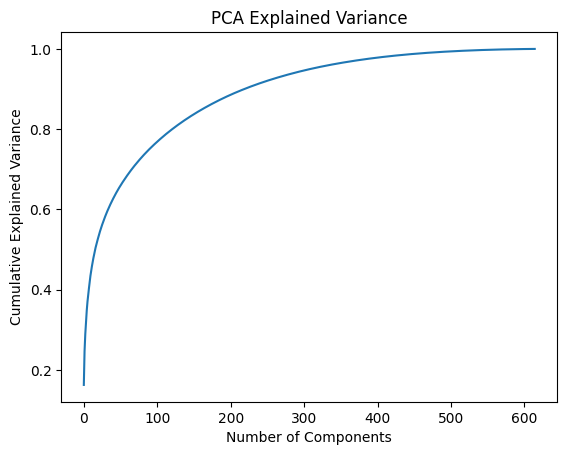

In [24]:
import matplotlib.pyplot as plt

plt.plot(pca.explained_variance_ratio_.cumsum())
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

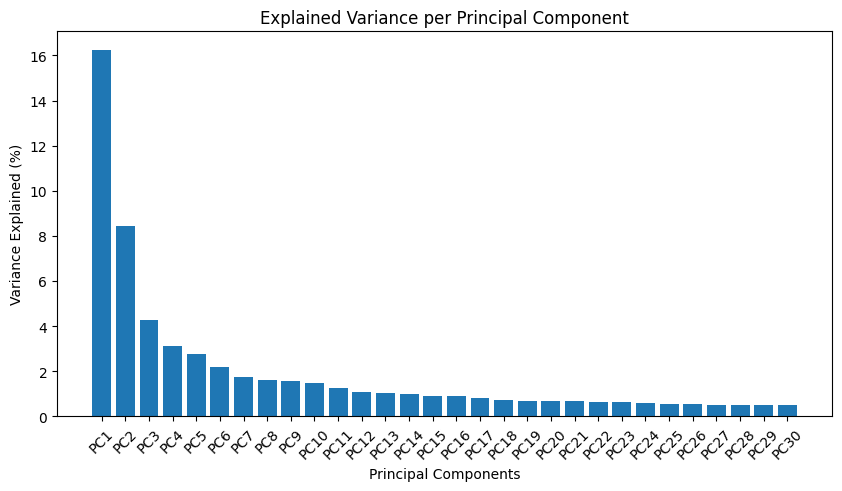

In [26]:
# percentage variance
explained_var = pca.explained_variance_ratio_ * 100

# take first 20 PCs (or any number)
n = 30

plt.figure(figsize=(10,5))
plt.bar(range(1, n+1), explained_var[:n])
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained (%)")
plt.title("Explained Variance per Principal Component")
plt.xticks(range(1, n+1), [f"PC{i}" for i in range(1, n+1)], rotation=45)
plt.show()

In [40]:
for i in [10, 20, 30, 40, 50]:
    var = pca.explained_variance_ratio_[:i].sum() * 100
    print(f"{i} PCs → {var:.2f}% variance")

10 PCs → 43.45% variance
20 PCs → 52.58% variance
30 PCs → 58.20% variance
40 PCs → 62.35% variance
50 PCs → 65.67% variance


1. The variance is distributed across many principal components, which is expected for high-dimensional biological data. Therefore, instead of relying on a small number of components, we retain multiple components (around 30–50) to preserve sufficient information for clustering.
2. The gradual variance accumulation indicates complex biological variability rather than noise. Therefore, instead of forcing high variance retention (90%), an optimal balance between dimensionality and information retention was chosen.

#####  Given the absence of a sharp variance cutoff and the gradual accumulation of explained variance, a moderate number of principal components (40) was selected to balance information retention and dimensionality reduction.

In [51]:
pca = PCA(n_components=40)
X_pca = pca.fit_transform(gene_scaled)

In [52]:
X_pca

array([[-20.65159899,   7.23391757,  -8.10612398, ...,   0.53317662,
          1.33117477,   2.22572735],
       [  3.629252  ,  11.76410947,  -0.61670468, ...,   0.33754022,
          2.08597572,   0.03390244],
       [  4.49258858,  12.26517812,  -1.34020849, ...,  -0.5993773 ,
          0.64447431,   1.77066142],
       ...,
       [  9.53856169,   3.25186779,   7.12127486, ...,   0.79320899,
          0.5091507 ,   1.05104972],
       [  4.23135535,   7.75428309,   0.73870463, ...,   0.59808701,
         -0.3183499 ,  -0.47487731],
       [ -5.93374886,  14.339258  ,   3.92153134, ...,   1.16970974,
         -1.660791  ,  -1.82027297]], shape=(615, 40))

### ELBOW METHOD
Helps estimate number of clusters (k)

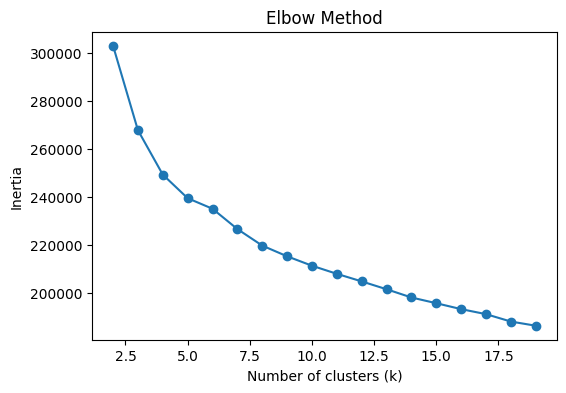

In [53]:
from sklearn.cluster import KMeans

inertia = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

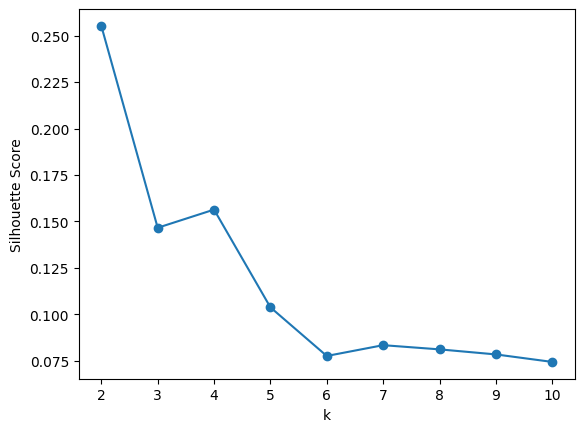

In [54]:
from sklearn.metrics import silhouette_score

sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

plt.plot(K, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

### Conclusion for PCA and Clustering Selection:

Principal Component Analysis (PCA) was applied to reduce the dimensionality 
of the gene expression data. The variance explained by principal components 
increased gradually, with the first 40 components capturing approximately 
62% of the total variance. This indicates that the data is highly complex 
and does not lie in a low-dimensional space, which is typical for biological datasets. 
Therefore, 40 principal components were retained to balance information retention 
and dimensionality reduction.

For clustering, the Elbow method showed a gradual decrease in inertia without a 
sharp elbow point, suggesting the absence of clearly separable clusters. The 
Silhouette scores were relatively low (≈0.15–0.25), indicating moderate cluster 
separation. However, such values are expected in high-dimensional biological data 
due to inherent heterogeneity and overlapping molecular characteristics.

Considering both the Elbow curve and Silhouette scores, along with prior biological 
knowledge (e.g., known breast cancer subtypes), k = 4 was selected as the optimal 
number of clusters. This choice balances interpretability and biological relevance, 
even in the absence of strongly separated clusters.

In [55]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca)

In [56]:
print(clusters[:10])

[1 2 2 2 2 2 3 2 3 3]


In [60]:
phenotype = data.iloc[:,:10]
phenotype.head()

,sample_id,age_at_initial_pathologic_diagnosis,gender,PAM50Call_RNAseq,ER_Status_nature2012,PR_Status_nature2012,HER2_Final_Status_nature2012,OS_Time_nature2012,OS_event_nature2012,final_stage
0,TCGA-A1-A0SB,70.0,FEMALE,Normal,Positive,Negative,Negative,259.0,0.0,Stage I
1,TCGA-A1-A0SD,59.0,FEMALE,LumA,Positive,Positive,Negative,437.0,0.0,Stage IIA
2,TCGA-A1-A0SE,56.0,FEMALE,LumA,Positive,Positive,Negative,1320.0,0.0,Stage I
3,TCGA-A1-A0SF,54.0,FEMALE,LumA,Positive,Positive,Negative,1463.0,0.0,Stage IIA
4,TCGA-A1-A0SG,61.0,FEMALE,LumA,Positive,Positive,Negative,433.0,0.0,Stage IIB


In [61]:
phenotype['cluster'] = clusters

In [62]:
phenotype['cluster'].value_counts()

cluster
2    210
0    197
1    105
3    103
Name: count, dtype: int64

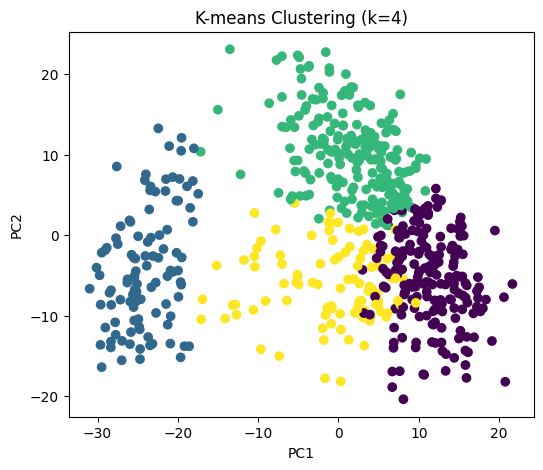

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clustering (k=4)")
plt.show()

* K-means clustering was applied to the PCA-transformed gene expression data 
using k = 4 clusters. Each patient was assigned to one of the four clusters 
based on similarity in molecular features.
* Clusters were visualized using the first two principal components (PC1 and PC2), which capture the maximum variance in the data. While clustering was performed using multiple components, the 2D projection provides an intuitive representation of cluster structure